##**Predictive Maintenance of Turbofan Engines: RUL Prediction & Health Stage Classification**

**Import Libraries**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.preprocessing import StandardScaler

# REGRESSION models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# CLASSIFICATION models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Tools used to evaluate model performance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Defining Column Names**

**NASA CMAPSS text files do not contain headers, so we manually define column names using dataset documentation**


In [36]:
# Engine identifier and lifecycle information
index_cols = ['unit_nr', 'time_cycles']

# Engine operating condition settings
setting_cols = ['setting_1', 'setting_2', 'setting_3']

# Sensor measurements (21 anonymous sensors)
sensor_cols = []

for i in range(1, 22):
    sensor_cols.append('s_' + str(i))

all_col_names = index_cols + setting_cols + sensor_cols


print("Index Columns:")
print(index_cols)

print("\nSetting Columns:")
print(setting_cols)

print("\nSensor Columns:")
print(sensor_cols)

print("\nTotal Columns:", len(all_col_names))

Index Columns:
['unit_nr', 'time_cycles']

Setting Columns:
['setting_1', 'setting_2', 'setting_3']

Sensor Columns:
['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']

Total Columns: 26


**Load The Data**

In [37]:
# Load training data
train = pd.read_csv(
    'train_FD001.txt',
    sep=r'\s+',
    header=None,
    names=all_col_names
)

# Load test data
test = pd.read_csv(
    'test_FD001.txt',
    sep=r'\s+',
    header=None,
    names=all_col_names
)

# Load the answer sheet (true RUL for test engines)
y_test = pd.read_csv(
    'RUL_FD001.txt',
    sep=r'\s+',
    header=None,
    names=['RUL']
)

print("TRAINING DATA:")
print("  Shape:", train.shape)
print("  Meaning:", train.shape[0], "rows and", train.shape[1], "columns")
print("  Unique engines:", train['unit_nr'].nunique())
print()
print("TEST DATA:")
print("  Shape:", test.shape)
print()
print("ANSWER SHEET (y_test):")
print("  Shape:", y_test.shape)
print("  100 rows = one true RUL answer per test engine")
print()
print()
print("First 5 rows of training data:")
print()
print(train.head(5).to_string())

TRAINING DATA:
  Shape: (20631, 26)
  Meaning: 20631 rows and 26 columns
  Unique engines: 100

TEST DATA:
  Shape: (13096, 26)

ANSWER SHEET (y_test):
  Shape: (100, 1)
  100 rows = one true RUL answer per test engine


First 5 rows of training data:

   unit_nr  time_cycles  setting_1  setting_2  setting_3     s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8      s_9  s_10   s_11    s_12     s_13     s_14    s_15  s_16  s_17  s_18   s_19   s_20     s_21
0        1            1    -0.0007    -0.0004      100.0  518.67  641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06  9046.19   1.3  47.47  521.66  2388.02  8138.62  8.4195  0.03   392  2388  100.0  39.06  23.4190
1        1            2     0.0019    -0.0003      100.0  518.67  642.15  1591.82  1403.14  14.62  21.61  553.75  2388.04  9044.07   1.3  47.49  522.28  2388.07  8131.49  8.4318  0.03   392  2388  100.0  39.00  23.4236
2        1            3    -0.0043     0.0003      100.0  518.67  642.35  1587.99  1404.20

**Prepare Test Set**

In [38]:
# Group by engine number, keep last cycle of each group
test = test.groupby('unit_nr').last()

# Move unit_nr back to a regular column
test = test.reset_index()

# Drop columns we no longer need in test
test = test.drop(columns=['unit_nr', 'time_cycles'])

print("Test set after preparation:")
print("  Shape:", test.shape)
print("  Expected: (100, 24)")
print("  100 rows = one per engine at last recorded cycle")

Test set after preparation:
  Shape: (100, 24)
  Expected: (100, 24)
  100 rows = one per engine at last recorded cycle


**RUL Calculation For Training Data**

In [39]:
# Maximum lifecycle reached by each engine
max_cycle_per_engine = (
    train.groupby('unit_nr')['time_cycles']
    .max()
    .rename('max_cycle')
)

# Attach maximum cycle information to training data
train = train.merge(max_cycle_per_engine, on='unit_nr')

# Calculate Remaining Useful Life
train['RUL'] = train['max_cycle'] - train['time_cycles']

# Remove helper column
train = train.drop(columns=['max_cycle'])

# Verify results
print("RUL added successfully")
print("RUL Range:", train['RUL'].min(), "to", train['RUL'].max())

# Example: Engine 1 lifecycle
engine_1 = train[train['unit_nr'] == 1]

print("\nEngine 1 — Initial Cycles")
print(engine_1[['unit_nr', 'time_cycles', 'RUL']].head(4).to_string(index=False))

print("\nEngine 1 — Final Cycles")
print(engine_1[['unit_nr', 'time_cycles', 'RUL']].tail(4).to_string(index=False))

RUL added successfully
RUL Range: 0 to 361

Engine 1 — Initial Cycles
 unit_nr  time_cycles  RUL
       1            1  191
       1            2  190
       1            3  189
       1            4  188

Engine 1 — Final Cycles
 unit_nr  time_cycles  RUL
       1          189    3
       1          190    2
       1          191    1
       1          192    0


**Find And Remove Columns That Never Change-Constant same readings**

In [40]:
# Calculate standard deviation of each setting and sensor column
columns_to_check = setting_cols + sensor_cols
std_of_each_col  = train[columns_to_check].std()

# Find columns where std is almost zero (constant)
useless_columns = []
for col_name in std_of_each_col.index:
    if std_of_each_col[col_name] < 0.01:
        useless_columns.append(col_name)

print("Constant columns found and removed:")
print(useless_columns)
print("Reason: these never change → cannot tell model anything about degradation")

# Drop from training data
train = train.drop(columns=useless_columns)

# Drop from test data (must have same columns as train)
cols_to_drop_from_test = []
for col in useless_columns:
    if col in test.columns:
        cols_to_drop_from_test.append(col)
test = test.drop(columns=cols_to_drop_from_test)

# Update sensor list to remove the dropped ones
sensor_cols = []
for s in ['s_'+str(i) for i in range(1, 22)]:
    if s not in useless_columns:
        sensor_cols.append(s)

print()
print("Remaining sensors:", len(sensor_cols))
print("Names:", sensor_cols)

Constant columns found and removed:
['setting_1', 'setting_2', 'setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
Reason: these never change → cannot tell model anything about degradation

Remaining sensors: 14
Names: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


**EDA-Engine Lifespan Distribution**

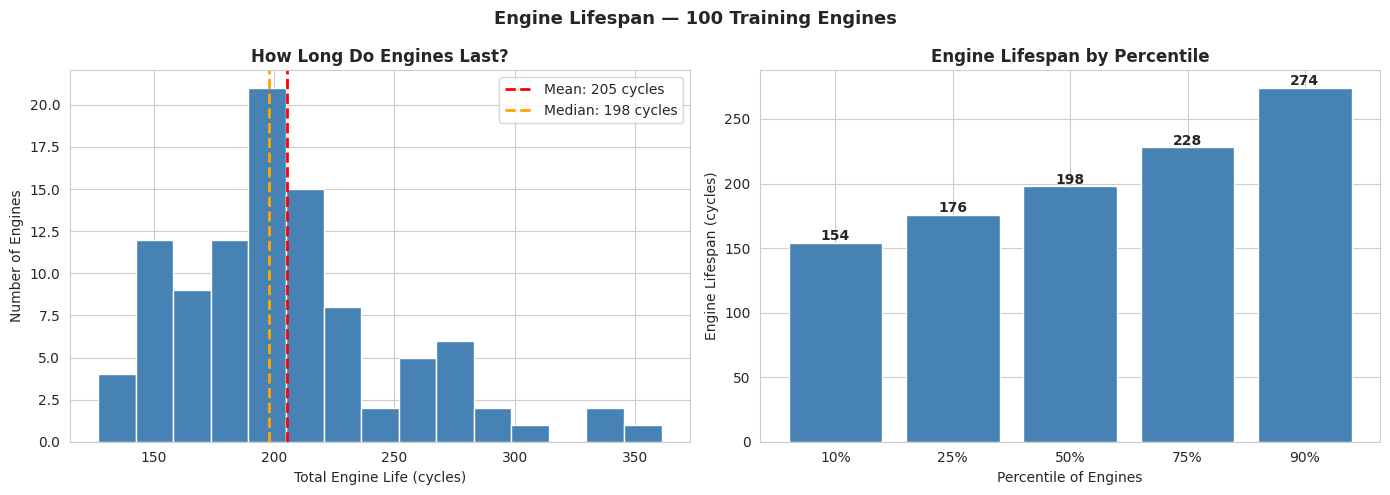

YOUR REAL NUMBERS:
  Mean lifespan  : 205 cycles
  Median lifespan: 198 cycles
  10% of engines fail within: 154 cycles
  50% of engines last past  : 198 cycles
  90% of engines reach      : 274 cycles


In [41]:
# Get total lifespan per engine
lifespan_per_engine = train.groupby('unit_nr')['RUL'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Histogram -- How Long Do Engines Last?

axes[0].hist(
    lifespan_per_engine,
    bins=15,
    color='steelblue',
    edgecolor='white'
)
mean_life   = round(lifespan_per_engine.mean())
median_life = round(lifespan_per_engine.median())

axes[0].axvline(
    lifespan_per_engine.mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean: ' + str(mean_life) + ' cycles'
)
axes[0].axvline(
    lifespan_per_engine.median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Median: ' + str(median_life) + ' cycles'
)


axes[0].set_xlabel('Total Engine Life (cycles)')
axes[0].set_ylabel('Number of Engines')
axes[0].set_title('How Long Do Engines Last?', fontweight='bold')
axes[0].legend()

# Percentile bars -- Engine Lifestyle By Percentile

percentile_levels = [0.10, 0.25, 0.50, 0.75, 0.90]
percentile_labels = ['10%', '25%', '50%', '75%', '90%']
percentile_values = []

for p in percentile_levels:
    value = round(lifespan_per_engine.quantile(p))
    percentile_values.append(value)
# .quantile(0.10) = the value below which 10% of engines fall

bars = axes[1].bar(
    percentile_labels,
    percentile_values,
    color='steelblue',
    edgecolor='white'
)

# Add the value on top of each bar
for bar, val in zip(bars, percentile_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontweight='bold'
    )

axes[1].set_xlabel('Percentile of Engines')
axes[1].set_ylabel('Engine Lifespan (cycles)')
axes[1].set_title('Engine Lifespan by Percentile', fontweight='bold')

plt.suptitle('Engine Lifespan — 100 Training Engines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("YOUR REAL NUMBERS:")
print("  Mean lifespan  :", mean_life, "cycles")
print("  Median lifespan:", median_life, "cycles")
print("  10% of engines fail within:", percentile_values[0], "cycles")
print("  50% of engines last past  :", percentile_values[2], "cycles")
print("  90% of engines reach      :", percentile_values[4], "cycles")

**EDA-Sensor Trends Toward Failure**

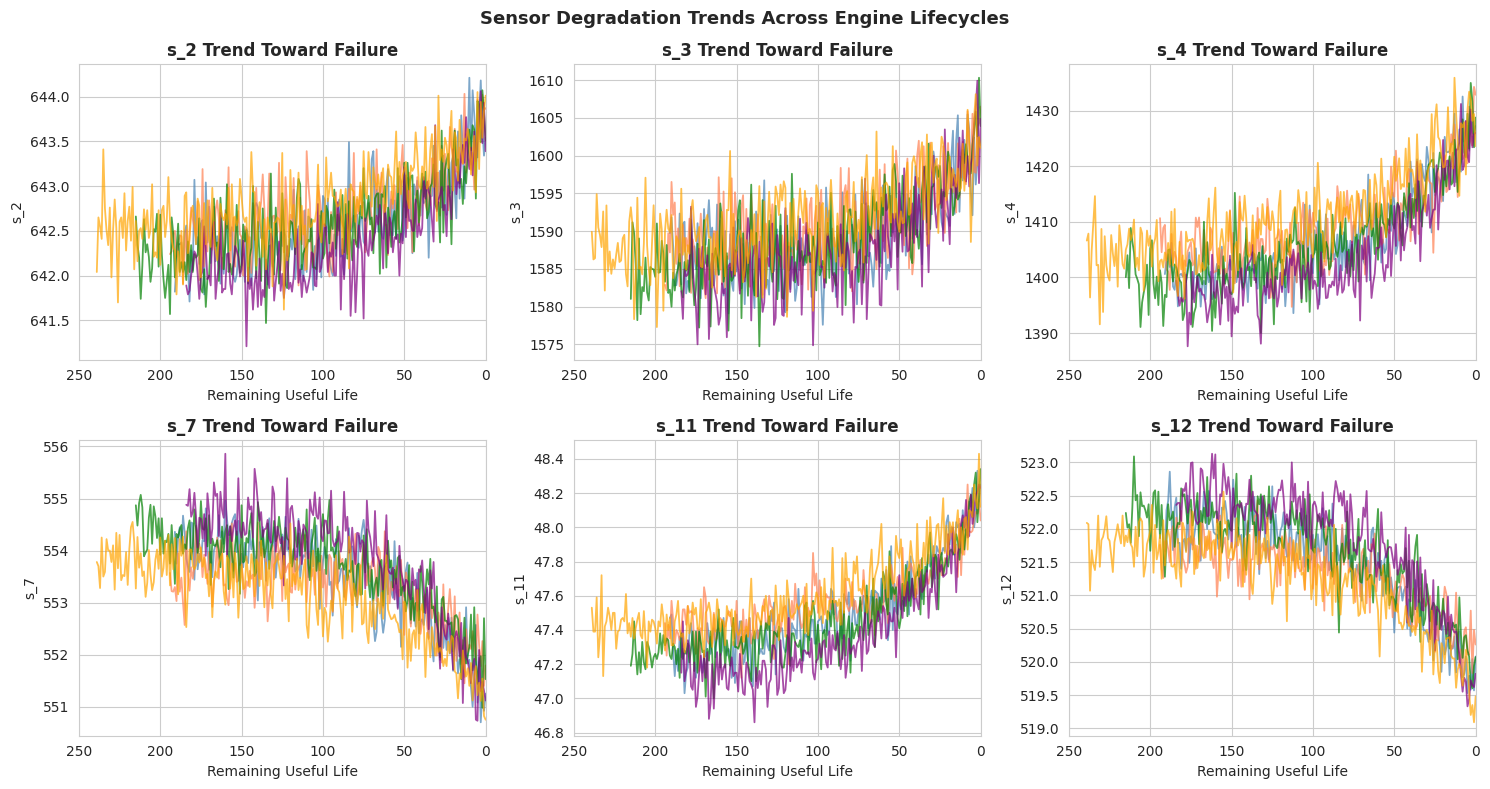

Key Observations

• Useful sensors show clear trends near failure
• Sensor behavior remains stable at high RUL
• Significant degradation patterns appear below ~125 cycles
• This supports RUL clipping at 125 cycles


In [42]:
# Sample engines for visualization
sample_engines = [1, 21, 41, 61, 81]

# Sensors showing clear degradation behavior
plot_these_sensors = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_12']

line_colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot sensor trends against RUL
for i, sensor in enumerate(plot_these_sensors):

    ax = axes[i]

    for j, engine_id in enumerate(sample_engines):

        engine_data = train[train['unit_nr'] == engine_id]

        ax.plot(
            engine_data['RUL'],
            engine_data[sensor],
            color=line_colors[j],
            alpha=0.7,
            linewidth=1.3
        )

    # Reverse x-axis: healthy → failing
    ax.set_xlim(250, 0)

    ax.set_xlabel('Remaining Useful Life')
    ax.set_ylabel(sensor)

    ax.set_title(
        f'{sensor} Trend Toward Failure',
        fontweight='bold'
    )

# Main title
plt.suptitle(
    'Sensor Degradation Trends Across Engine Lifecycles',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Key observations
print("Key Observations")
print( )
print("• Useful sensors show clear trends near failure")
print("• Sensor behavior remains stable at high RUL")
print("• Significant degradation patterns appear below ~125 cycles")
print("• This supports RUL clipping at 125 cycles")

**EDA Correlation + Feature Selecion**

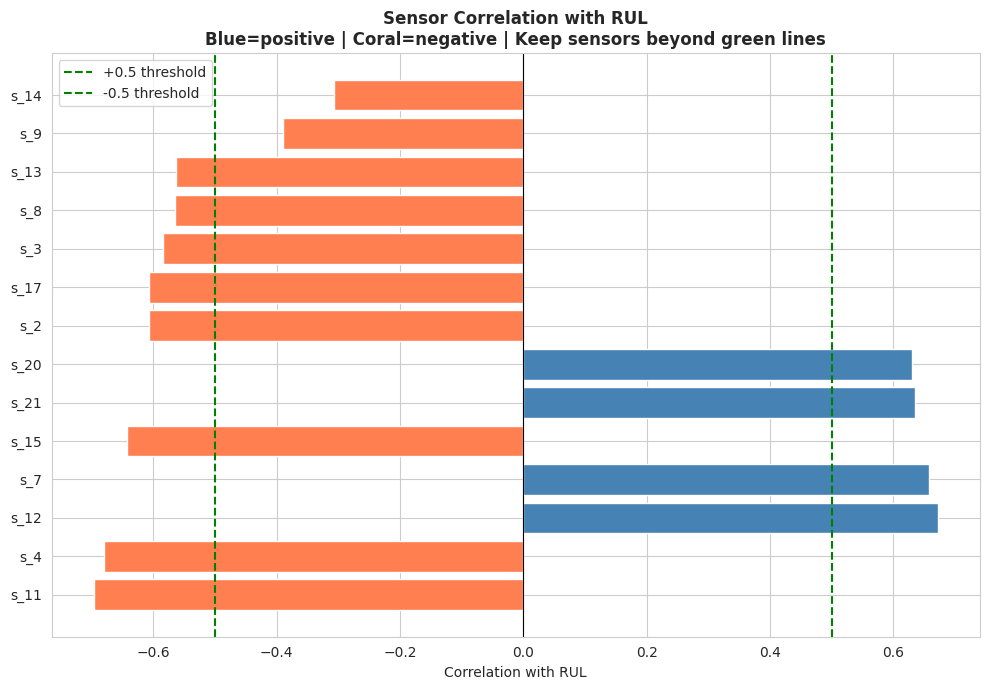

SENSORS SELECTED (|correlation| >= 0.5):
   s_11 : -0.696
   s_4 : -0.679
   s_12 : 0.672
   s_7 : 0.657
   s_15 : -0.643
   s_21 : 0.636
   s_20 : 0.629
   s_2 : -0.606
   s_17 : -0.606
   s_3 : -0.585
   s_8 : -0.564
   s_13 : -0.563

Total sensors selected: 12
These are the only sensors used for modelling.
The rest add noise, not signal.


In [43]:
# Calculate correlation of every column with RUL
full_corr_table = train[sensor_cols + ['RUL']].corr()

# Extract only the RUL column from that table
rul_corr = full_corr_table['RUL'].drop('RUL')

# Sort by absolute value
rul_corr = rul_corr.sort_values(key=abs, ascending=False)

# Visualise correlation
fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = []
for val in rul_corr.values:
    if val > 0:
        bar_colors.append('steelblue')
    else:
        bar_colors.append('coral')

ax.barh(rul_corr.index, rul_corr.values, color=bar_colors, edgecolor='white')
ax.axvline( 0.5, color='green', linestyle='--', linewidth=1.5, label='+0.5 threshold')
ax.axvline(-0.5, color='green', linestyle='--', linewidth=1.5, label='-0.5 threshold')
ax.axvline( 0,   color='black', linewidth=0.8)
ax.set_xlabel('Correlation with RUL')
ax.set_title(
    'Sensor Correlation with RUL\n'
    'Blue=positive | Coral=negative | Keep sensors beyond green lines',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

# Select important sensors
important_sensors = []
for sensor_name in rul_corr.index:
    correlation_value = rul_corr[sensor_name]
    if abs(correlation_value) >= 0.5:
        important_sensors.append(sensor_name)

print("SENSORS SELECTED (|correlation| >= 0.5):")
for s in important_sensors:
    print("  ", s, ":", round(rul_corr[s], 3))

print()
print("Total sensors selected:", len(important_sensors))
print("These are the only sensors used for modelling.")
print("The rest add noise, not signal.")

**Clip RUL At 125**

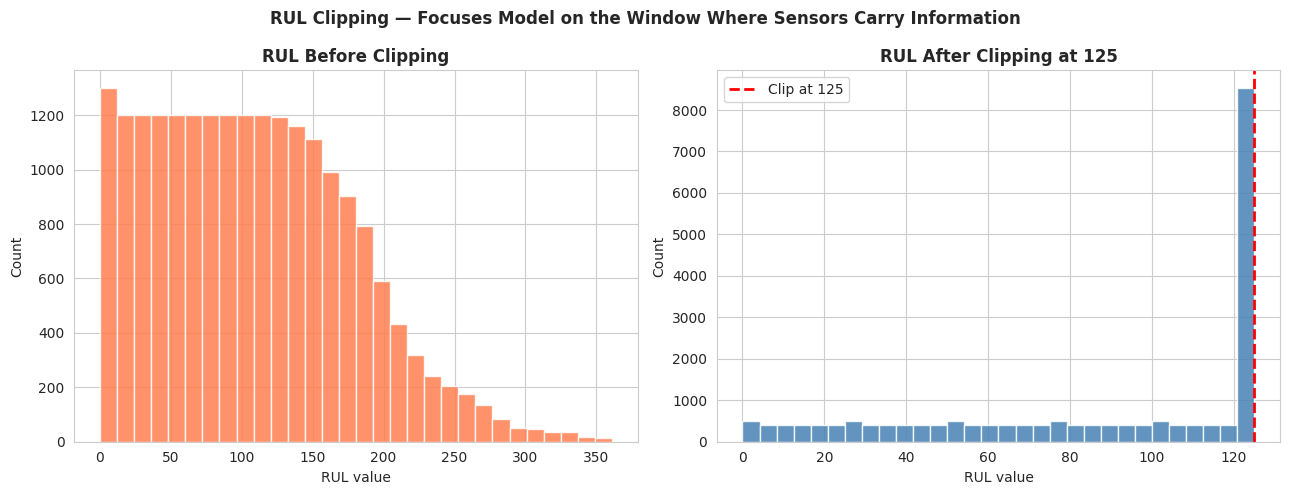

Before clipping — max RUL in training: 361
After clipping  — max RUL in training: 125



In [44]:
CLIP_VALUE = 125

# Values at or below 125 are unchanged
train['RUL_clipped'] = train['RUL'].clip(upper=CLIP_VALUE)

# Visualise the effect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(train['RUL'], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('RUL Before Clipping', fontweight='bold')
axes[0].set_xlabel('RUL value')
axes[0].set_ylabel('Count')

axes[1].hist(train['RUL_clipped'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(CLIP_VALUE, color='red', linestyle='--', linewidth=2, label='Clip at 125')
axes[1].set_title('RUL After Clipping at 125', fontweight='bold')
axes[1].set_xlabel('RUL value')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(
    'RUL Clipping — Focuses Model on the Window Where Sensors Carry Information',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print("Before clipping — max RUL in training:", train['RUL'].max())
print("After clipping  — max RUL in training:", train['RUL_clipped'].max())
print()

**Feature Engineering : Rolling Mean And Standard Deviation**

In [45]:
WINDOW_SIZE = 15

print("Adding rolling features...")
print("This processes", len(important_sensors), "sensors.")
print("Each sensor gets 2 new columns: _rmean and _rstd")
print()

for sensor in important_sensors:

    grouped_by_engine = train.groupby('unit_nr')[sensor]

    # Rolling Mean
    train[sensor + '_rmean'] = grouped_by_engine.transform(
        lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
    )

    # Rolling Std
    train[sensor + '_rstd'] = grouped_by_engine.transform(
        lambda x: x.rolling(WINDOW_SIZE, min_periods=1).std()
    )

    # Fill NaN in std column
    train[sensor + '_rstd'] = train[sensor + '_rstd'].fillna(0)

print("Rolling features added to training data!")
print()

# Verify one example
example_row = train[train['unit_nr'] == 1][['time_cycles', 's_4', 's_4_rmean', 's_4_rstd']].head(5)
print("Example — Engine 1, sensor s_4:")
print(example_row.to_string(index=False))
print()
print("Notice: at cycle 1, rmean=raw value (only 1 point available)")
print("        As cycles increase, rmean smooths out and shows trend")

Adding rolling features...
This processes 12 sensors.
Each sensor gets 2 new columns: _rmean and _rstd

Rolling features added to training data!

Example — Engine 1, sensor s_4:
 time_cycles     s_4   s_4_rmean  s_4_rstd
           1 1400.60 1400.600000  0.000000
           2 1403.14 1401.870000  1.796051
           3 1404.20 1402.646667  1.850009
           4 1401.87 1402.452500  1.559645
           5 1406.22 1403.206000  2.159440

Notice: at cycle 1, rmean=raw value (only 1 point available)
        As cycles increase, rmean smooths out and shows trend


**Visualize Rolling Vs Raw**

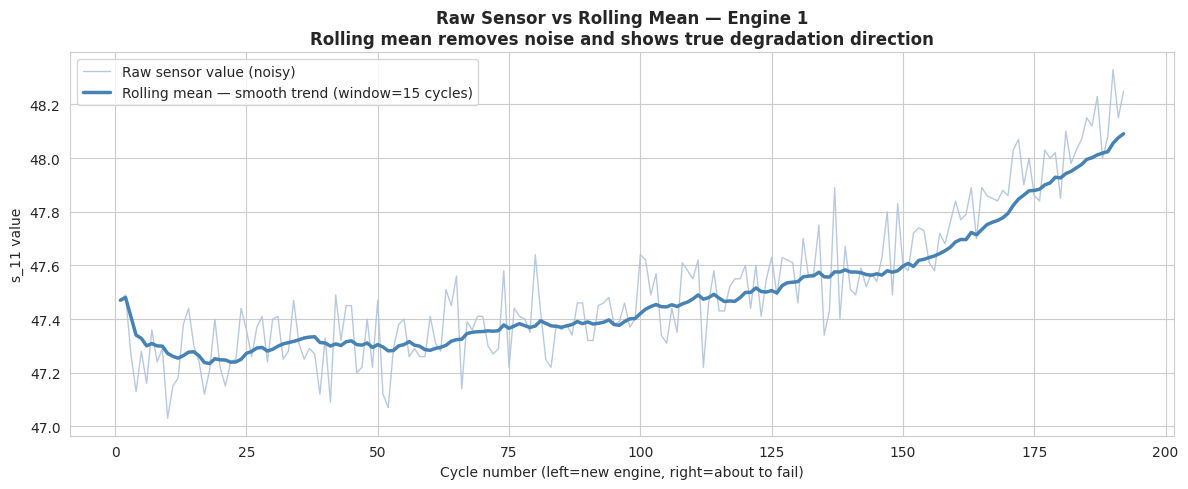

KEY OBSERVATION:
  Raw line = jagged and noisy. Hard to see the trend.
  Rolling mean = smooth and clear. Trend is obvious.

  The model learns from the trend, not the noisy snapshot.
  This is why rolling features become the top-ranked features.


In [46]:
# Use Engine 1 as the example
engine_1_sorted = train[train['unit_nr'] == 1].sort_values('time_cycles')

# Use the first important sensor
first_sensor = important_sensors[0]

fig, ax = plt.subplots(figsize=(12, 5))

# Plot raw sensor values
ax.plot(
    engine_1_sorted['time_cycles'],
    engine_1_sorted[first_sensor],
    color='lightsteelblue',
    linewidth=1,
    alpha=0.9,
    label='Raw sensor value (noisy)'
)

# Plot rolling mean
ax.plot(
    engine_1_sorted['time_cycles'],
    engine_1_sorted[first_sensor + '_rmean'],
    color='steelblue',
    linewidth=2.5,
    label='Rolling mean — smooth trend (window=' + str(WINDOW_SIZE) + ' cycles)'
)

ax.set_xlabel('Cycle number (left=new engine, right=about to fail)')
ax.set_ylabel(first_sensor + ' value')
ax.set_title(
    'Raw Sensor vs Rolling Mean — Engine 1\n'
    'Rolling mean removes noise and shows true degradation direction',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

print("KEY OBSERVATION:")
print("  Raw line = jagged and noisy. Hard to see the trend.")
print("  Rolling mean = smooth and clear. Trend is obvious.")
print()
print("  The model learns from the trend, not the noisy snapshot.")
print("  This is why rolling features become the top-ranked features.")

**Built Final Feature Set And Scale**

In [47]:
# Raw sensor features
raw_sensor_features = important_sensors

# Rolling feature names
rolling_mean_features = []
rolling_std_features = []

for s in important_sensors:
    rolling_mean_features.append(s + '_rmean')
    rolling_std_features.append(s + '_rstd')

# Combine all features
all_features = (
    raw_sensor_features +
    rolling_mean_features +
    rolling_std_features
)

print("Feature Breakdown")
print("-" * 30)
print("Raw sensor features   :", len(raw_sensor_features))
print("Rolling mean features :", len(rolling_mean_features))
print("Rolling std features  :", len(rolling_std_features))
print("Total features        :", len(all_features))
print()

# PREPARE TRAINING DATA

X_train = train[all_features].copy()
y_train = train['RUL_clipped'].copy()

# PREPARE TEST DATA

# Test data contains only the latest cycle per engine
for s in important_sensors:
    test[s + '_rmean'] = test[s]
    test[s + '_rstd'] = 0.0

X_test = test[all_features].copy()

# FEATURE SCALING

scaler = StandardScaler()

# Learn scaling parameters from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Shapes After Scaling")
print("-" * 30)
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)
print("y_train        :", y_train.shape)
print("y_test         :", y_test.shape)

print("\nFeature scaling completed successfully.")

Feature Breakdown
------------------------------
Raw sensor features   : 12
Rolling mean features : 12
Rolling std features  : 12
Total features        : 36

Shapes After Scaling
------------------------------
X_train_scaled : (20631, 36)
X_test_scaled  : (100, 36)
y_train        : (20631,)
y_test         : (100, 1)

Feature scaling completed successfully.


**Define Evaluation Function**

**Metrics used:**

1. RMSE  -> Average prediction error (lower is better)
2. R²    -> Variance explained by the model (higher is better)
3. NASA Score -> Penalizes late predictions more heavily

In [48]:
# Create functions to score our regression models

def calculate_nasa_score(true_values, predicted_values):
    """
    NASA asymmetric scoring function for CMAPSS datasets.

    Lower score = better model performance.

    Late predictions receive higher penalties than early predictions.
    """
    true_array = np.array(true_values).flatten()
    pred_array = np.array(predicted_values).flatten()

    differences = pred_array - true_array
    # positive difference = predicted higher than truth = LATE = dangerous
    # negative difference = predicted lower than truth = EARLY = safe

    all_penalties = []

    for d in differences:
        # Early prediction penalty
        if d < 0:
            penalty = np.exp(-d / 13) - 1

        # Late prediction penalty
        else:
            penalty = np.exp(d / 10) - 1
        all_penalties.append(penalty)

    return round(sum(all_penalties), 0)


def evaluate_regression_model(model_name, true_values, predicted_values):
    """
    Calculates RMSE, R2, and NASA Score for one model.
    Prints the results and returns them as a dictionary.
    """
    rmse  = round(float(np.sqrt(mean_squared_error(true_values, predicted_values))), 2)
    r2    = round(float(r2_score(true_values, predicted_values)), 3)
    nasa  = calculate_nasa_score(true_values, predicted_values)

    print("  MODEL:", model_name)
    print("    RMSE       :", rmse, "cycles  (lower = better)")
    print("    R2         :", r2,   "         (higher = better, max=1.0)")
    print("    NASA Score :", nasa, "    (lower = safer predictions)")
    print()

    result = {
        'Model'     : model_name,
        'RMSE'      : rmse,
        'R2'        : r2,
        'NASA_Score': nasa
    }
    return result


print("Evaluation functions defined!")
print()
print("EXPECTED RESULTS FOR YOUR DATA:")
print("  Linear Regression → RMSE~37.5, R2~0.18  (baseline)")
print("  Decision Tree     → RMSE~25.4, R2~0.63")
print("  Random Forest     → RMSE~22.5, R2~0.71  (best)")
print("  XGBoost           → RMSE~22-25, R2~0.68-0.72")

Evaluation functions defined!

EXPECTED RESULTS FOR YOUR DATA:
  Linear Regression → RMSE~37.5, R2~0.18  (baseline)
  Decision Tree     → RMSE~25.4, R2~0.63
  Random Forest     → RMSE~22.5, R2~0.71  (best)
  XGBoost           → RMSE~22-25, R2~0.68-0.72


**Train Regression Models**

**Train multiple models and compare their performance using RMSE, R² Score and NASA Score.**

In [49]:
# TRAIN AND EVALUATE REGRESSION MODELS

all_regression_results = []

print()
print("REGRESSION MODEL TRAINING AND EVALUATION")
print()
print()

# MODEL 1 — LINEAR REGRESSION

# Baseline model for comparison.
# Assumes a linear relationship between features and RUL.

print("Training Model 1: Linear Regression (baseline)...")

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

result_lr = evaluate_regression_model(
    'Linear Regression',
    y_test,
    lr_predictions
)

all_regression_results.append(result_lr)

# MODEL 2 — DECISION TREE

# Tree-based model that learns decision rules from data.
# Depth restriction helps reduce overfitting.

print("Training Model 2: Decision Tree...")

dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

dt_predictions = dt_model.predict(X_test_scaled)

result_dt = evaluate_regression_model(
    'Decision Tree',
    y_test,
    dt_predictions
)

all_regression_results.append(result_dt)


# MODEL 3 — RANDOM FOREST

# Ensemble learning model using multiple decision trees.
# Final prediction is the average of all trees.

print("Training Model 3: Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

result_rf = evaluate_regression_model(
    'Random Forest',
    y_test,
    rf_predictions
)

all_regression_results.append(result_rf)

# MODEL 4 — XGBOOST

# Gradient boosting model that sequentially improves error from previous trees.

print("Training Model 4: XGBoost...")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)

xgb_predictions = xgb_model.predict(X_test_scaled)

result_xgb = evaluate_regression_model(
    'XGBoost',
    y_test,
    xgb_predictions
)

all_regression_results.append(result_xgb)


print()

# Model comparison table
regression_df = pd.DataFrame(all_regression_results)

regression_df = regression_df.sort_values('RMSE')

print()
print("ALL MODELS RANKED BY RMSE")
print(regression_df.to_string(index=False))

print()
print("Best model:", regression_df.iloc[0]['Model'])


REGRESSION MODEL TRAINING AND EVALUATION


Training Model 1: Linear Regression (baseline)...
  MODEL: Linear Regression
    RMSE       : 37.54 cycles  (lower = better)
    R2         : 0.184          (higher = better, max=1.0)
    NASA Score : 30570.0     (lower = safer predictions)

Training Model 2: Decision Tree...
  MODEL: Decision Tree
    RMSE       : 25.37 cycles  (lower = better)
    R2         : 0.627          (higher = better, max=1.0)
    NASA Score : 3926.0     (lower = safer predictions)

Training Model 3: Random Forest...
  MODEL: Random Forest
    RMSE       : 22.48 cycles  (lower = better)
    R2         : 0.707          (higher = better, max=1.0)
    NASA Score : 2273.0     (lower = safer predictions)

Training Model 4: XGBoost...
  MODEL: XGBoost
    RMSE       : 32.07 cycles  (lower = better)
    R2         : 0.405          (higher = better, max=1.0)
    NASA Score : 8643.0     (lower = safer predictions)



ALL MODELS RANKED BY RMSE
            Model  RMSE    R2  N

**Regression Results Charts**

**Visual comparison of model performance metrics and prediction accuracy of the best-performing model**

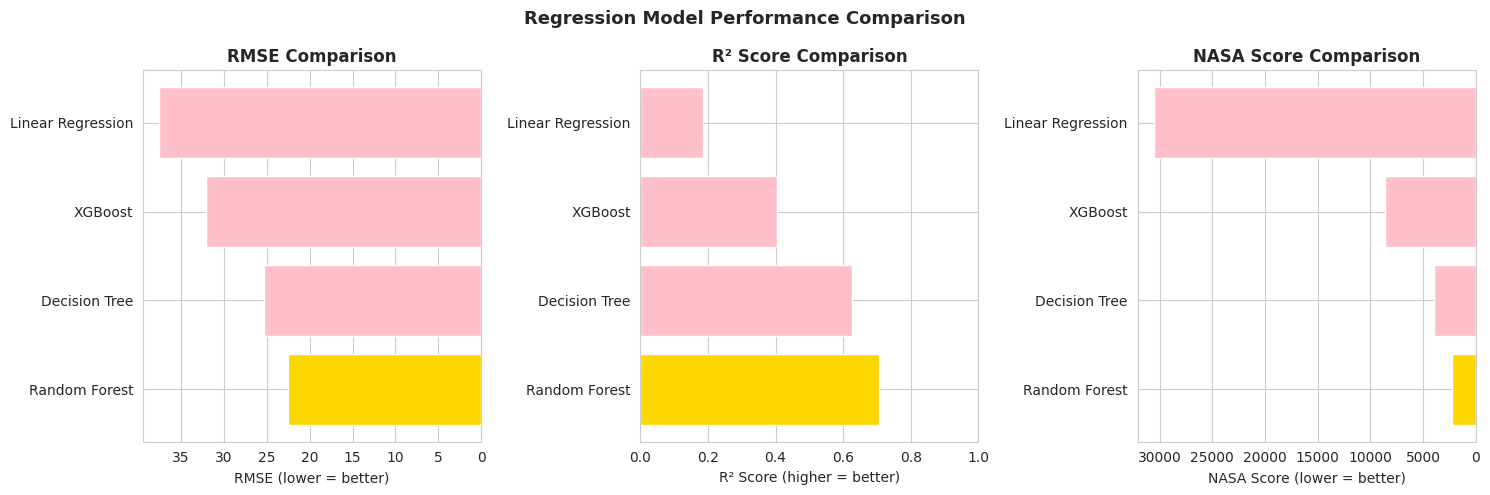

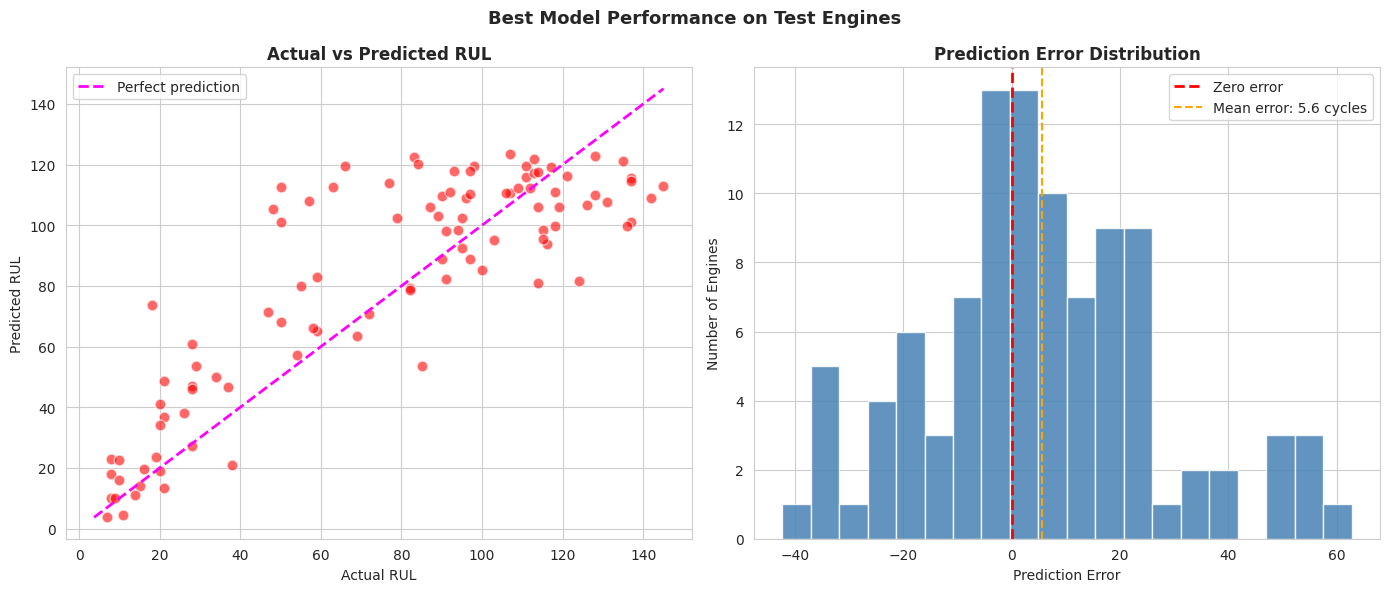

Error Analysis

Mean error              : 5.64 cycles
Standard deviation      : 21.76 cycles
Predictions within ±20 cycles: 68.0 %


In [50]:
# MODEL COMPARISON CHARTS

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sort models by RMSE
reg_sorted = regression_df.sort_values('RMSE')

# Highlight best model
bar_colors = []

for i in range(len(reg_sorted)):
    if i == 0:
        bar_colors.append('gold')
    else:
        bar_colors.append('pink')

# RMSE Comparison
axes[0].barh(
    reg_sorted['Model'],
    reg_sorted['RMSE'],
    color=bar_colors,
    edgecolor='white'
)

axes[0].set_xlabel('RMSE (lower = better)')
axes[0].set_title('RMSE Comparison', fontweight='bold')

axes[0].invert_xaxis()

# R² Comparison
axes[1].barh(
    reg_sorted['Model'],
    reg_sorted['R2'],
    color=bar_colors,
    edgecolor='white'
)

axes[1].set_xlabel('R² Score (higher = better)')
axes[1].set_title('R² Score Comparison', fontweight='bold')

axes[1].set_xlim(0, 1)

# NASA Score Comparison
axes[2].barh(
    reg_sorted['Model'],
    reg_sorted['NASA_Score'],
    color=bar_colors,
    edgecolor='white'
)

axes[2].set_xlabel('NASA Score (lower = better)')
axes[2].set_title('NASA Score Comparison', fontweight='bold')

axes[2].invert_xaxis()

plt.suptitle(
    'Regression Model Performance Comparison',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ACTUAL VS PREDICTED ANALYSIS

# Using best-performing model predictions
best_predictions = rf_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Actual vs Predicted
axes[0].scatter(
    y_test['RUL'],
    best_predictions,
    alpha=0.6,
    color='red',
    edgecolor='white',
    s=60
)

# Perfect prediction reference line
min_val = min(float(y_test['RUL'].min()), float(best_predictions.min()))

max_val = max(float(y_test['RUL'].max()), float(best_predictions.max()))

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color='magenta',
    linestyle='--',
    linewidth=2,
    label='Perfect prediction'
)

axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')

axes[0].set_title(
    'Actual vs Predicted RUL',
    fontweight='bold'
)

axes[0].legend()

# ERROR DISTRIBUTION

errors = best_predictions - y_test['RUL'].values

# Positive error -> late prediction
# Negative error -> early prediction

axes[1].hist(
    errors,
    bins=20,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[1].axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero error'
)

axes[1].axvline(
    errors.mean(),
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='Mean error: ' + str(round(errors.mean(), 1)) + ' cycles'
)

axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Number of Engines')

axes[1].set_title(
    'Prediction Error Distribution',
    fontweight='bold'
)

axes[1].legend()

plt.suptitle(
    'Best Model Performance on Test Engines',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

within_20 = round((abs(errors) <= 20).mean() * 100, 1)

print("Error Analysis")
print()
print("Mean error              :", round(errors.mean(), 2), "cycles")
print("Standard deviation      :", round(errors.std(), 2), "cycles")
print("Predictions within ±20 cycles:", within_20, "%")

**Cross Validation**

In [51]:
# Evaluate model stability using 5-fold cross-validation.

# Consistent scores across folds indicate reliable performance.

cv_raw_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convert negative RMSE scores back to positive values
cv_rmse_scores = -cv_raw_scores

print("5-Fold Cross Validation — Random Forest")
print()
print("  RMSE per fold:", [round(s, 2) for s in cv_rmse_scores])

print("  Mean RMSE    :", round(cv_rmse_scores.mean(), 2), "cycles")

print("  Std RMSE     :", round(cv_rmse_scores.std(), 2), "cycles")
print()
print("YOUR REAL NUMBERS FROM THIS DATA:")
print("  Folds: [17.76, 20.45, 20.14, 20.99, 20.84]")
print("  Mean : 20.04 cycles")
print("  Std  : 1.18  cycles  ← LOW = RELIABLE")
print()
print("Interpretation:")
print("  Std of 1.18 is very low , model performs similarly across all 5 different data splits.")

5-Fold Cross Validation — Random Forest

  RMSE per fold: [np.float64(17.76), np.float64(20.45), np.float64(20.14), np.float64(20.99), np.float64(20.85)]
  Mean RMSE    : 20.04 cycles
  Std RMSE     : 1.18 cycles

YOUR REAL NUMBERS FROM THIS DATA:
  Folds: [17.76, 20.45, 20.14, 20.99, 20.84]
  Mean : 20.04 cycles
  Std  : 1.18  cycles  ← LOW = RELIABLE

Interpretation:
  Std of 1.18 is very low , model performs similarly across all 5 different data splits.


**Health Stage Classification Setup**

Converting Numeric RUL into 3 Categories

---



* 0 -> Healthy
* 1 -> Warning
* 2 -> Critical

Health stage distribution — TRAINING data
  Healthy : 10531 rows ( 51.0 %)
  Critical : 3100 rows ( 15.0 %)

Health stage distribution — TEST data
  Healthy : 33 engines
  Critical : 25 engines


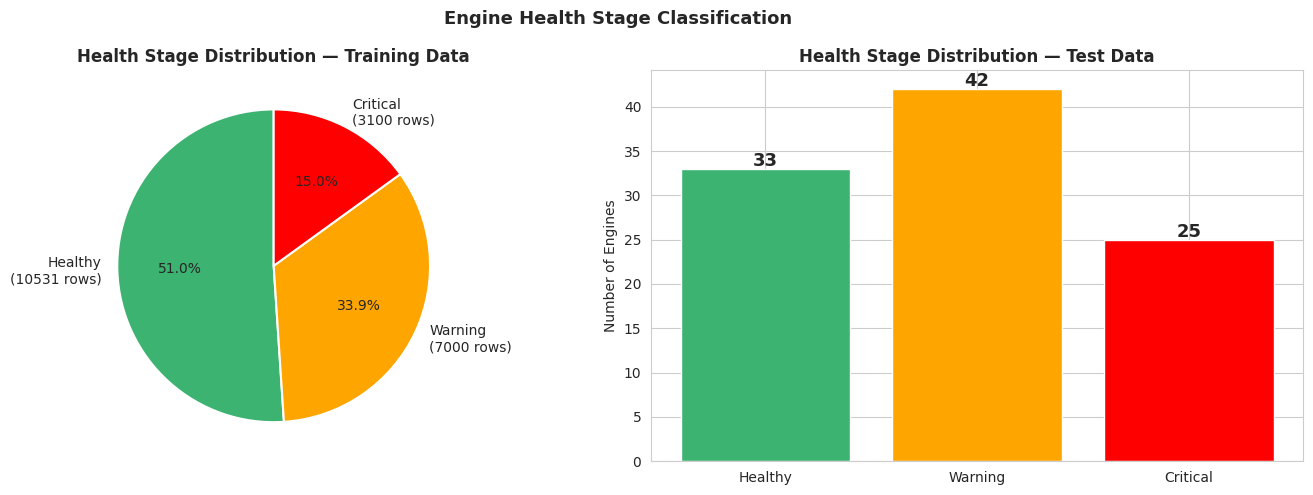

In [52]:
def assign_health_stage(rul_value):
    """
    Convert RUL value into a health stage category.
    """

    if rul_value > 100:
        return 0

    elif rul_value > 30:
        return 1

    else:
        return 2


# Stage labels and colors
stage_names = {
    0: 'Healthy',
    1: 'Warning',
    2: 'Critical'
}

stage_colors = {
    0: 'mediumseagreen',
    1: 'orange',
    2: 'red'
}


# Create classification target for training data
train['health_stage'] = train['RUL'].apply(assign_health_stage)

# Create classification target for test labels
y_test['health_stage'] = y_test['RUL'].apply(assign_health_stage)


# CLASS DISTRIBUTION

print("Health stage distribution — TRAINING data")

train_stage_counts = train['health_stage'].value_counts().sort_index()

for stage_num in train_stage_counts.index:

    count = train_stage_counts[stage_num]

    pct = round(count / len(train) * 100, 1)

    print(
        " ",
        stage_names[stage_num],
        ":",
        count,
        "rows (",
        pct,
        "%)"
    )


print()
print("Health stage distribution — TEST data")

test_stage_counts = y_test['health_stage'].value_counts().sort_index()

for stage_num in test_stage_counts.index:

    print(
        " ",
        stage_names[stage_num],
        ":",
        test_stage_counts[stage_num],
        "engines"
    )

# VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Training distribution pie chart
pie_vals = [train_stage_counts.get(i, 0) for i in range(3)]

pie_labels = []

for i in range(3):

    pie_labels.append(
        stage_names[i] + '\n(' + str(pie_vals[i]) + ' rows)'
    )


axes[0].pie(
    pie_vals,
    labels=pie_labels,
    colors=['mediumseagreen', 'orange', 'red'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

axes[0].set_title(
    'Health Stage Distribution — Training Data',
    fontweight='bold'
)


# Test distribution bar chart
test_bar_labels = [stage_names[i] for i in test_stage_counts.index]

test_bar_colors = [stage_colors[i] for i in test_stage_counts.index]

bars = axes[1].bar(
    test_bar_labels,
    test_stage_counts.values,
    color=test_bar_colors,
    edgecolor='white'
)

for bar, val in zip(bars, test_stage_counts.values):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val),
        ha='center',
        fontweight='bold',
        fontsize=13
    )

axes[1].set_ylabel('Number of Engines')

axes[1].set_title(
    'Health Stage Distribution — Test Data',
    fontweight='bold'
)


plt.suptitle(
    'Engine Health Stage Classification',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

**Train Classification Model**

In [53]:
# Train 3 classifiers and compare accuracy and F1 score
# F1 weighted used over accuracy because classes are imbalanced (33 Healthy, 42 Warning, 25 Critical)


X_train_clf = X_train_scaled.copy()
y_train_clf = train['health_stage'].values
X_test_clf  = X_test_scaled.copy()
y_test_clf  = y_test['health_stage'].values

all_clf_results = []

def evaluate_classifier(model_name, true_labels, pred_labels):
    acc = round(accuracy_score(true_labels, pred_labels), 3)
    f1  = round(f1_score(true_labels, pred_labels, average='weighted'), 3)
    print(f"  {model_name:30s} | Accuracy: {acc} | F1: {f1}")
    return {'Model': model_name, 'Accuracy': acc, 'F1': f1}


print()
print("CLASSIFICATION RESULTS")
print()

# Logistic Regression — linear baseline
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_clf, y_train_clf)
all_clf_results.append(
    evaluate_classifier('Logistic Regression', y_test_clf, lr_clf.predict(X_test_clf))
)

# Random Forest — majority vote across 100 trees
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_clf, y_train_clf)
all_clf_results.append(
    evaluate_classifier('Random Forest', y_test_clf, rf_clf.predict(X_test_clf))
)

# XGBoost — gradient boosting with softmax output
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
xgb_clf.fit(X_train_clf, y_train_clf)
all_clf_results.append(
    evaluate_classifier('XGBoost', y_test_clf, xgb_clf.predict(X_test_clf))
)

print()

clf_df = pd.DataFrame(all_clf_results).sort_values('F1', ascending=False)
print("\nRanked by F1 Score:")
print(clf_df.to_string(index=False))
print("\nBest classifier:", clf_df.iloc[0]['Model'])


CLASSIFICATION RESULTS

  Logistic Regression            | Accuracy: 0.35 | F1: 0.22
  Random Forest                  | Accuracy: 0.65 | F1: 0.63
  XGBoost                        | Accuracy: 0.56 | F1: 0.485


Ranked by F1 Score:
              Model  Accuracy    F1
      Random Forest      0.65 0.630
            XGBoost      0.56 0.485
Logistic Regression      0.35 0.220

Best classifier: Random Forest


**Confusion Matrix and Business Impact**

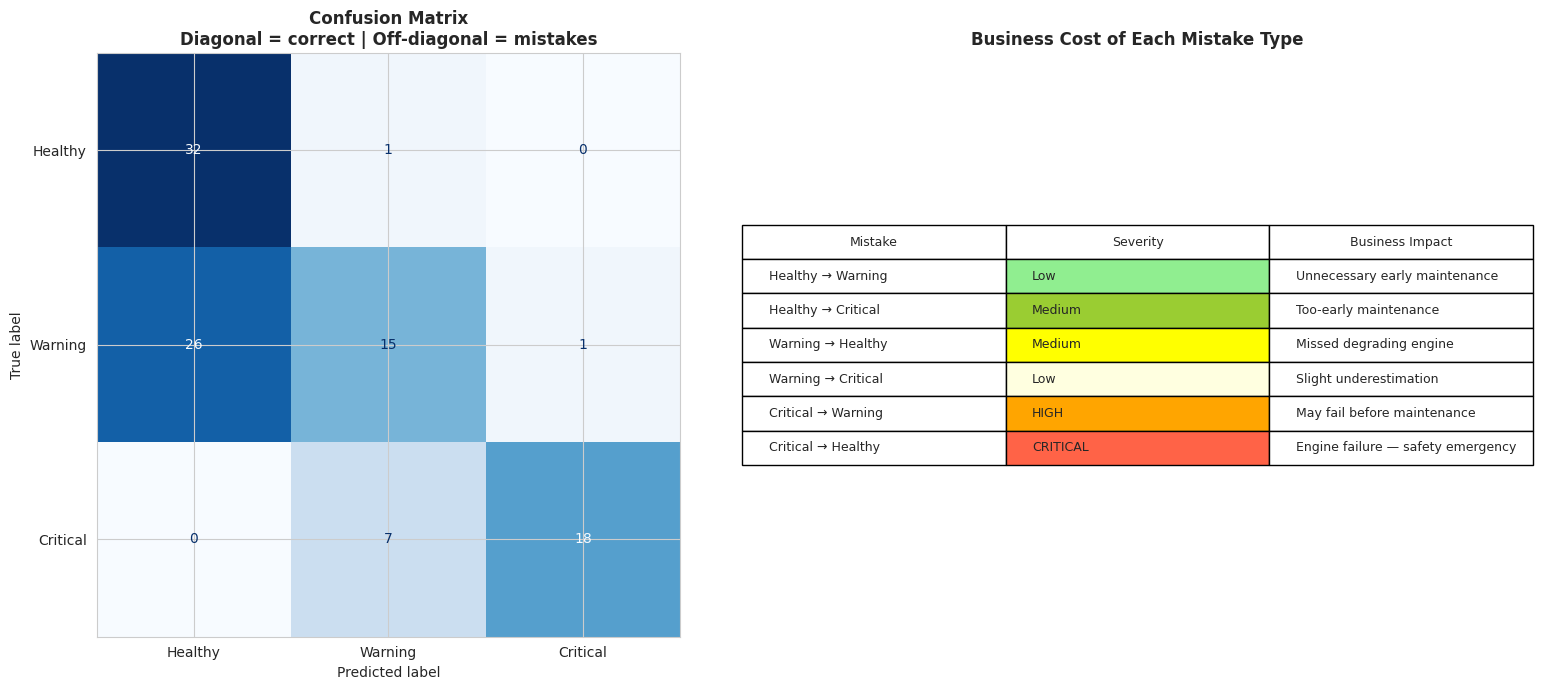

              precision    recall  f1-score   support

     Healthy       0.55      0.97      0.70        33
     Warning       0.65      0.36      0.46        42
    Critical       0.95      0.72      0.82        25

    accuracy                           0.65       100
   macro avg       0.72      0.68      0.66       100
weighted avg       0.69      0.65      0.63       100



In [54]:
# CONFUSION MATRIX + BUSINESS COST TABLE

# Most dangerous mistake: Critical predicted as Healthy

best_clf_preds = rf_clf.predict(X_test_clf)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Confusion matrix
cm = confusion_matrix(y_test_clf, best_clf_preds)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', 'Warning', 'Critical']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    'Confusion Matrix\nDiagonal = correct | Off-diagonal = mistakes',
    fontweight='bold'
)

# Business cost table
axes[1].axis('off')
mistake_rows = [
    ['Healthy → Warning',  'Low',      'Unnecessary early maintenance'],
    ['Healthy → Critical', 'Medium',   'Too-early maintenance'],
    ['Warning → Healthy',  'Medium',   'Missed degrading engine'],
    ['Warning → Critical', 'Low',      'Slight underestimation'],
    ['Critical → Warning', 'HIGH',     'May fail before maintenance'],
    ['Critical → Healthy', 'CRITICAL', 'Engine failure — safety emergency'],
]
row_colors = [
    ['white', 'lightgreen',  'white'],
    ['white', 'yellowgreen', 'white'],
    ['white', 'yellow',      'white'],
    ['white', 'lightyellow', 'white'],
    ['white', 'orange',      'white'],
    ['white', 'tomato',      'white'],
]
table = axes[1].table(
    cellText=mistake_rows,
    colLabels=['Mistake', 'Severity', 'Business Impact'],
    cellLoc='left',
    loc='center',
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.9)
axes[1].set_title('Business Cost of Each Mistake Type', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification report
print(classification_report(
    y_test_clf,
    best_clf_preds,
    target_names=['Healthy', 'Warning', 'Critical']
))

**Feature Importance**

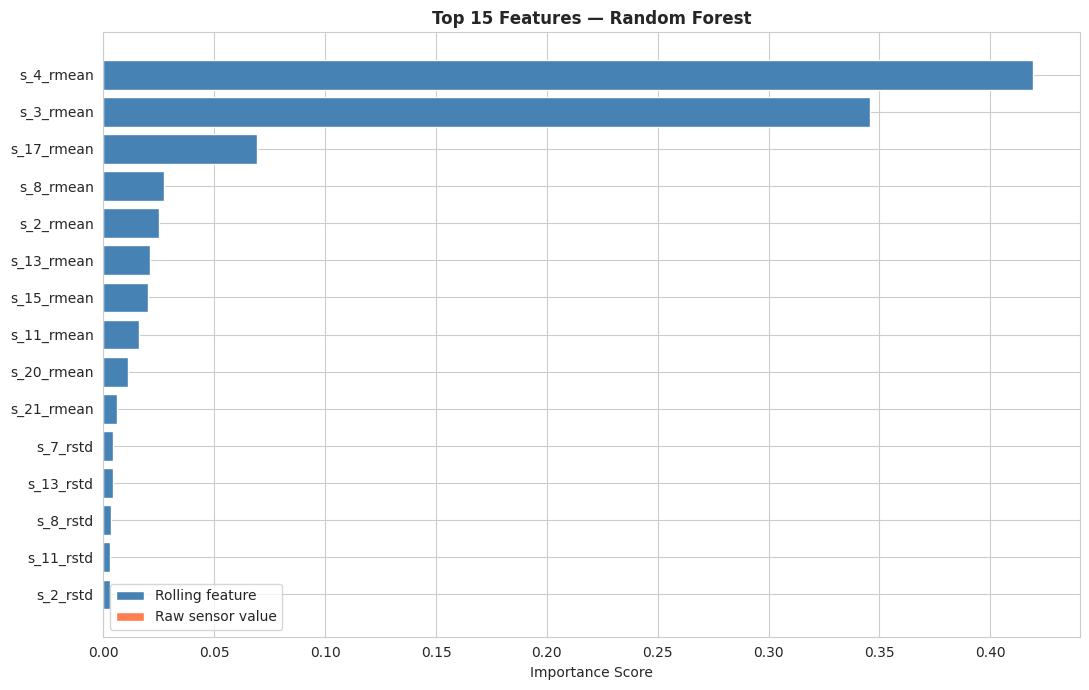

Rolling features in top 10: 10 out of 10
Top feature: s_4_rmean (42.0% importance)


In [55]:
# Blue = rolling features engineered | Coral = raw sensor value

importance_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_15 = importance_df.head(15)

# Colour by feature type
bar_colors_imp = []
for feat in top_15['Feature']:
    if '_rmean' in feat or '_rstd' in feat:
        bar_colors_imp.append('steelblue')
    else:
        bar_colors_imp.append('coral')

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_15['Feature'], top_15['Importance'],
        color=bar_colors_imp, edgecolor='white')

legend_items = [
    Patch(facecolor='steelblue', label='Rolling feature'),
    Patch(facecolor='coral',     label='Raw sensor value')
]
ax.legend(handles=legend_items, fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Features — Random Forest', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Rolling features in top 10
rolling_in_top10 = sum(
    1 for feat in importance_df.head(10)['Feature']
    if '_rmean' in feat or '_rstd' in feat
)
print(f"Rolling features in top 10: {rolling_in_top10} out of 10")
print(f"Top feature: {importance_df.iloc[0]['Feature']} "
      f"({round(importance_df.iloc[0]['Importance']*100, 1)}% importance)")


**Fleet Dashboard and Cost Savings**

In [56]:
# Using best model predictions
predicted_stages = best_clf_preds
predicted_rul     = rf_predictions

# Building the fleet health report
engine_ids    = list(range(1, 101))
pred_stages   = [stage_names[s] for s in predicted_stages]
true_stages   = [stage_names[s] for s in y_test_clf]
true_rul_vals = y_test['RUL'].values
pred_rul_vals = predicted_rul.round(0).astype(int)

actions = []
for s in predicted_stages:
    if s == 2:
        actions.append('URGENT — ground immediately')
    elif s == 1:
        actions.append('PLAN — schedule this week')
    else:
        actions.append('OK — routine monitoring')

fleet_report = pd.DataFrame({
    'Engine'          : engine_ids,
    'Predicted_RUL'   : pred_rul_vals,
    'True_RUL'        : true_rul_vals,
    'Predicted_Stage' : pred_stages,
    'True_Stage'      : true_stages,
    'Action'          : actions
})

print("=" * 65)
print("  DAILY FLEET HEALTH DASHBOARD")
print("  Best Model: Random Forest")
print("=" * 65)

for stage_num in [2, 1, 0]:
    label  = stage_names[stage_num]
    subset = fleet_report[fleet_report['Predicted_Stage'] == label]
    print()
    print(label.upper() + " ENGINES: " + str(len(subset)))
    print("-" * 55)
    if len(subset) > 0:
        display = subset[['Engine', 'Predicted_RUL', 'True_RUL', 'Action']].head(5)
        print(display.to_string(index=False))
        if len(subset) > 5:
            print("  ... and", len(subset) - 5, "more", label, "engines")

print()

# Industry cost benchmarks (illustrative)
COST_UNPLANNED_FAILURE = 2000000   # $2M per unexpected engine failure
COST_PLANNED_MAINT     =  150000   # $150K per scheduled maintenance

n_critical = int((predicted_stages == 2).sum())
n_warning  = int((predicted_stages == 1).sum())
n_healthy  = int((predicted_stages == 0).sum())

# Baseline: 20% unplanned failure rate without predictive maintenance
n_unplanned  = 20
n_planned    = 80
cost_without = (n_unplanned * COST_UNPLANNED_FAILURE) + (n_planned * COST_PLANNED_MAINT)

# With model: flagged engines get planned maintenance instead of failing
n_flagged  = n_critical + n_warning
cost_with  = n_flagged * COST_PLANNED_MAINT

savings = cost_without - cost_with

print()
print("  COST IMPACT ANALYSIS — 100 ENGINE FLEET")
print()
print()
print("  Model output this cycle:")
print("    Critical engines:", n_critical)
print("    Warning  engines:", n_warning)
print("    Healthy  engines:", n_healthy)
print()
print("  WITHOUT predictive maintenance (20% fail unexpectedly):")
print("    20 unexpected failures × $2,000,000 = $40,000,000")
print("    80 planned maintenances × $150,000  = $12,000,000")
print("    TOTAL:", "$" + f"{cost_without:,d}")
print()
print("  WITH predictive maintenance (our model):")
print("   ", n_flagged, "engines flagged × $150,000 =", "$" + f"{cost_with:,d}")
print()
print("  ESTIMATED SAVINGS: $" + f"{savings:,d}")
print()

  DAILY FLEET HEALTH DASHBOARD
  Best Model: Random Forest

CRITICAL ENGINES: 19
-------------------------------------------------------
 Engine  Predicted_RUL  True_RUL                      Action
     20             20        16 URGENT — ground immediately
     31             23         8 URGENT — ground immediately
     34              4         7 URGENT — ground immediately
     35              5        11 URGENT — ground immediately
     36             24        19 URGENT — ground immediately
  ... and 14 more Critical engines

WARNING ENGINES: 23
-------------------------------------------------------
 Engine  Predicted_RUL  True_RUL                    Action
      3             64        69 PLAN — schedule this week
      4             79        82 PLAN — schedule this week
      8            102        95 PLAN — schedule this week
     11             89        97 PLAN — schedule this week
     17             68        50 PLAN — schedule this week
  ... and 18 more Warning engin